Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame'in ilk 5 satırı:
                 time   sv        SNR   SNR_Std  Pseudorange  Label  \
0 2026-01-01 00:02:30  G32  51.300000  0.450833  21292457.92      0   
1 2026-01-01 00:03:00  G12  42.050000  1.248799  24630650.52      0   
2 2026-01-01 00:03:30  G28  49.968976  0.050000  21282990.24      2   
3 2026-01-01 00:04:00  G12  40.850000  0.909258  24667479.72      0   
4 2026-01-01 00:04:30  G23  47.050000  0.777335  22963942.92      0   

   time_diff  snr_rolling_std  pseudorange_diff  snr_gradient  
0       30.0         4.659399       -3301560.70      0.366667  
1       30.0         3.335866          18341.02     -0.016667  
2       30.0         3.628960        -774565.26      0.033966  
3       30.0         4.093043        3477134.36     -0.273333  
4       30.0         4.314452        1687548.62     -0.126667  

DataFrame Bilgisi:
<class 'panda

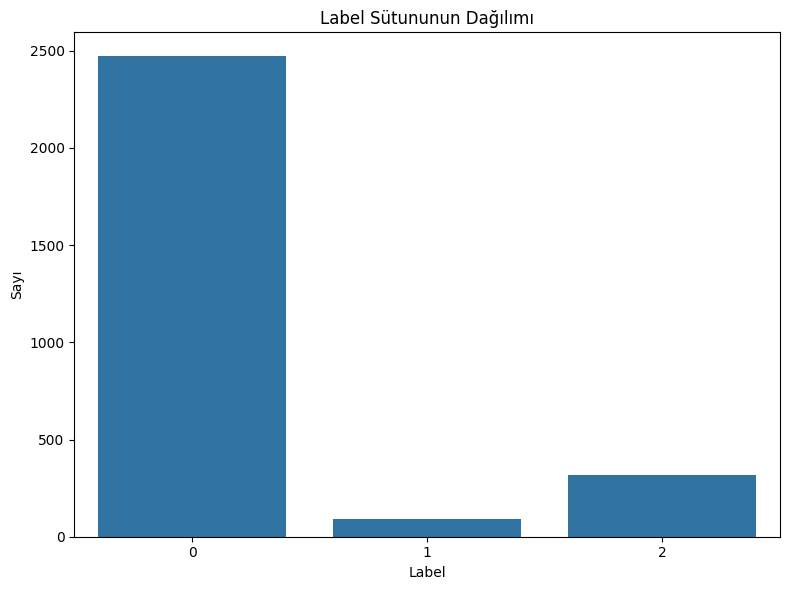

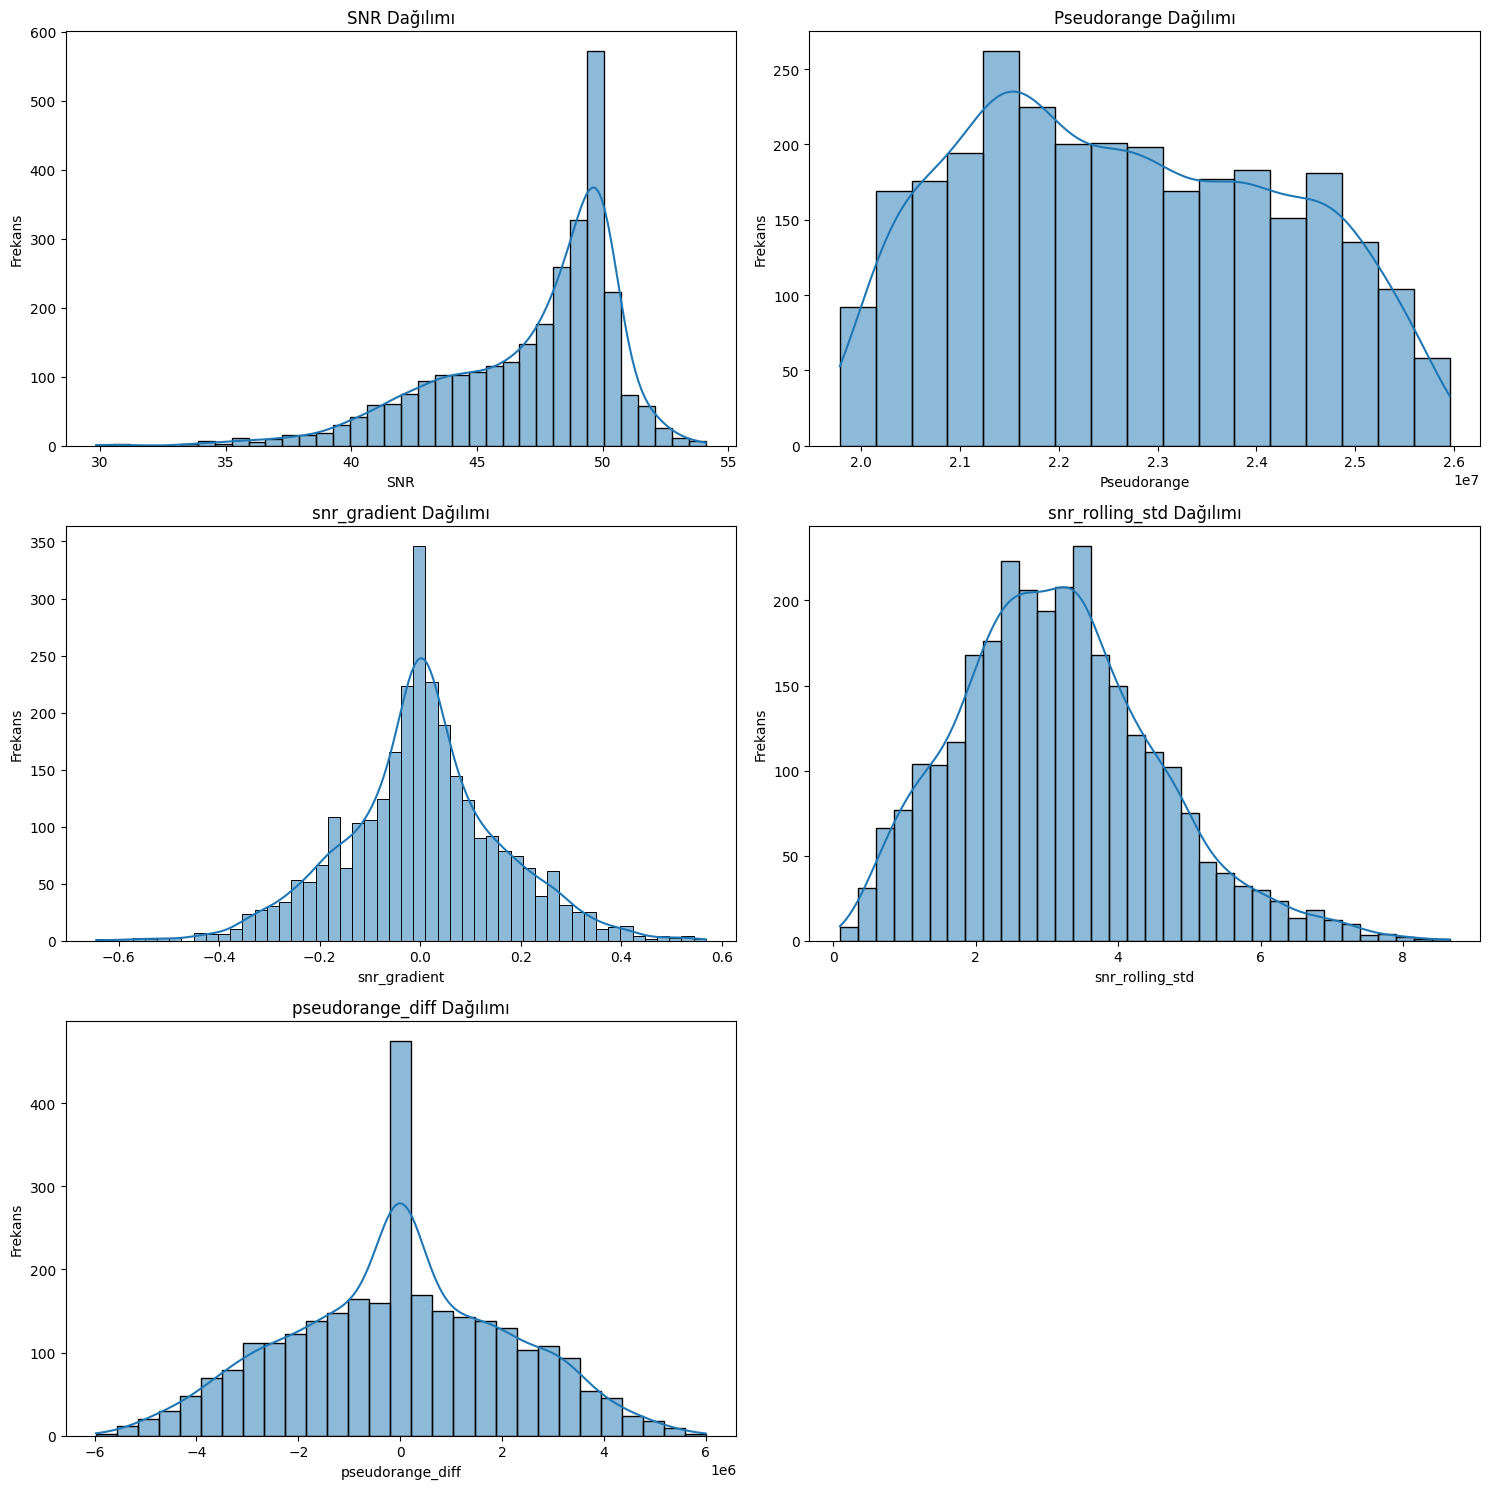

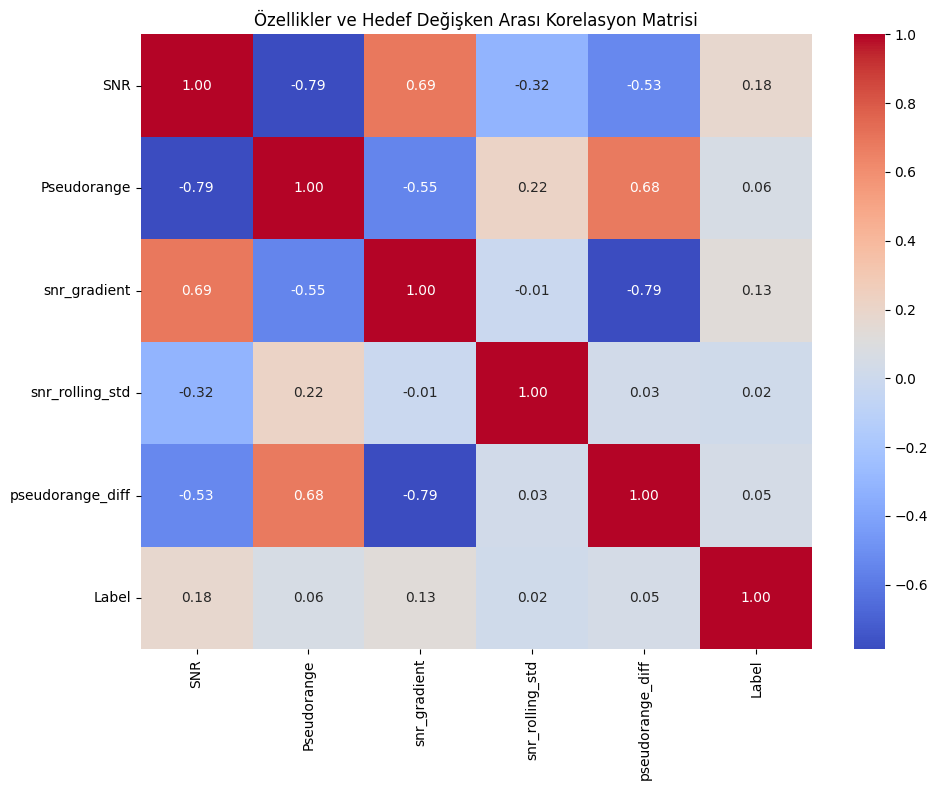


'Label' ile Özellik Korelasyonları (büyükten küçüğe):
Label               1.000000
SNR                 0.177420
snr_gradient        0.131183
Pseudorange         0.060694
pseudorange_diff    0.048261
snr_rolling_std     0.018950
Name: Label, dtype: float64

Eğitim seti boyutu : 2300
Test seti boyutu   : 575

── Model Sonuçları (Zamansal Bölme) ──
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       499
           1       0.00      0.00      0.00        25
           2       0.87      0.92      0.90        51

    accuracy                           0.94       575
   macro avg       0.60      0.64      0.62       575
weighted avg       0.90      0.94      0.92       575



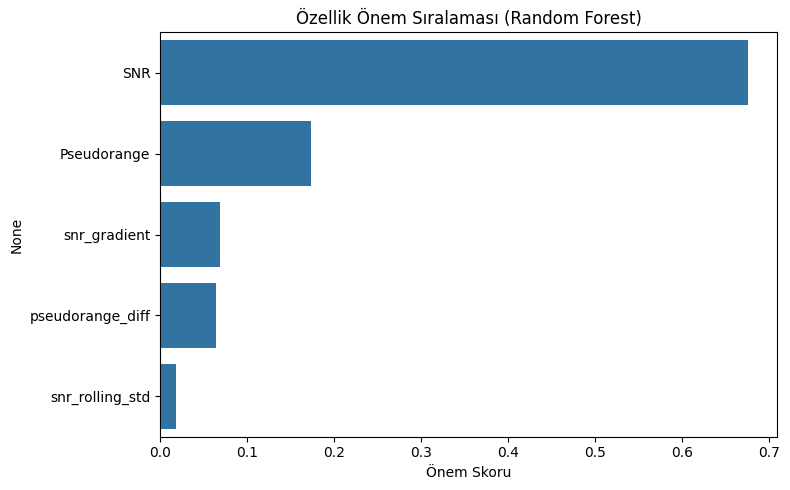

In [ ]:
# ============================================================
# GNSS Spoofing Tespiti - Düzeltilmiş ve Optimize Edilmiş Kod
# ============================================================

# ── 0. Google Drive bağlantısı (HER ŞEYDEN ÖNCE) ──────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 1. Kütüphaneler ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ── 2. Veri Yükleme ───────────────────────────────────────────
path = "/content/drive/MyDrive/vega/gnss3.csv"
df = pd.read_csv(path)
df = df.dropna().reset_index(drop=True)

# ── 3. Zaman İşlemleri ────────────────────────────────────────
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)   # Zamansal sırayı garanti et

df['time_diff'] = df['time'].diff().dt.total_seconds()

# DÜZELTME #1: time_diff = 0 olan satırlar sonsuz gradyan üretir → NaN yap
df['time_diff'] = df['time_diff'].replace(0, np.nan)

# ── 4. Özellik Mühendisliği ───────────────────────────────────

# Sinyal gürültüsü (5'lik pencere std) — ilk 4 satır NaN olarak kalır, drop edilecek
df['snr_rolling_std'] = df['SNR'].rolling(window=5).std()

# Pseudorange anlık sıçramaları
df['pseudorange_diff'] = df['Pseudorange'].diff()

# DÜZELTME #2: Gerçek residual yerine sadece merkeze alma yapılıyordu;
#              bu özellik Pseudorange ile %100 korelasyonlu olduğundan KALDIRILDI.
#              (Pseudorange - mean(Pseudorange) ekstra bilgi taşımaz)

# SNR gradyanı — time_diff NaN olan yerlerde sonuç da NaN olur (güvenli)
df['snr_gradient'] = df['SNR'].diff() / df['time_diff']

# DÜZELTME #3: inf değerlerini de temizle (dropna() tek başına inf'i silmez)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

# ── 5. Özellik Listesi ────────────────────────────────────────
# pseudorange_residual kaldırıldı (Pseudorange ile korelasyon = 1.0 → anlamsız)
features = [
    'SNR',
    'Pseudorange',
    'snr_gradient',
    'snr_rolling_std',
    'pseudorange_diff'
]

X = df[features]
y = df['Label']

# ── 6. Keşifsel Veri Analizi ──────────────────────────────────

# Genel bakış
print("=" * 60)
print("DataFrame'in ilk 5 satırı:")
print(df.head())

print("\nDataFrame Bilgisi:")
df.info()

print("\nEksik değer sayısı (temizlik sonrası):")
print(df.isnull().sum())

print("\nTanımlayıcı İstatistikler:")
print(df.describe())

print("\n'Label' sütununun değer dağılımı:")
print(df['Label'].value_counts())

# Label dağılımı
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df)
plt.title('Label Sütununun Dağılımı')
plt.xlabel('Label')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

# Özellik histogramları
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'{feature} Dağılımı')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekans')

# Fazladan eksen varsa gizle
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Korelasyon matrisi
correlation_matrix = df[features + ['Label']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Özellikler ve Hedef Değişken Arası Korelasyon Matrisi')
plt.tight_layout()
plt.show()

print("\n'Label' ile Özellik Korelasyonları (büyükten küçüğe):")
print(correlation_matrix['Label'].sort_values(ascending=False))

# ── 7. Modelleme ──────────────────────────────────────────────

# DÜZELTME #4: Zamansal sıra korunarak train/test bölmesi (data leakage önlendi)
# Rastgele karıştırma (shuffle) GNSS zaman serisi için yanlış sonuç üretir.
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"\nEğitim seti boyutu : {len(X_train)}")
print(f"Test seti boyutu   : {len(X_test)}")

# Aşırı öğrenmeyi önlemek için kısıtlı Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,         # Ağaç derinliği sınırlı
    min_samples_leaf=20, # Genelleme için minimum yaprak örneği
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n" + "=" * 60)
print("── Model Sonuçları (Zamansal Bölme) ──")
print(classification_report(y_test, y_pred))

# Özellik önem sıralaması
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Özellik Önem Sıralaması (Random Forest)')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
from pyngrok import ngrok
import subprocess
import os
import time

# Eğer açık bir ngrok tüneli varsa kapat
print("Mevcut ngrok tünelleri kapatılıyor...")
ngrok.kill()

# Streamlit'in varsayılan portu
streamlit_port = 8501

# ngrok tüneli başlat
print(f"ngrok tüneli başlatılıyor (port: {streamlit_port})...")
tunnel = ngrok.connect(streamlit_port)
public_url = tunnel.public_url
print(f"Streamlit uygulamanıza buradan erişin: {public_url}")

# Streamlit uygulamasını başlat (non-blocking)
print("Streamlit uygulaması başlatılıyor...")

# Arka planda çalıştır
streamlit_process = subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", str(streamlit_port),
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

# Küçük bir bekleme, Streamlit’in hazır hale gelmesi için
time.sleep(5)

print("Streamlit ve ngrok aktif. Linkten erişebilirsiniz.")

Mevcut ngrok tünelleri kapatılıyor...
ngrok tüneli başlatılıyor (port: 8501)...
Streamlit uygulamanıza buradan erişin: https://chairborne-elma-nonexplanatory.ngrok-free.dev
Streamlit uygulaması başlatılıyor...
Streamlit ve ngrok aktif. Linkten erişebilirsiniz.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from streamlit_folium import st_folium
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

st.set_page_config(page_title="GNSS Antispoofing Dashboard", layout="wide", initial_sidebar_state="collapsed")

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600&display=swap');
    html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; background-color: #0a0e1a; color: #e0e6f0; }
    .stApp { background: #0a0e1a; }
    .dashboard-header { background: linear-gradient(135deg, #0d1526, #091020); border-bottom: 1px solid #1e3a5f; padding: 20px 32px 16px 32px; }
    .dashboard-title { font-family: 'Space Mono', monospace; font-size: 1.6rem; font-weight: 700; color: #00d4ff; letter-spacing: 0.08em; text-transform: uppercase; margin: 0; }
    .dashboard-subtitle { font-size: 0.8rem; color: #4a7fa5; letter-spacing: 0.15em; text-transform: uppercase; margin-top: 4px; }
    .stat-card { background: linear-gradient(135deg, #0d1a2e, #0a1525); border: 1px solid #1e3a5f; border-radius: 8px; padding: 16px 20px; text-align: center; }
    .stat-value { font-family: 'Space Mono', monospace; font-size: 1.8rem; font-weight: 700; color: #00d4ff; line-height: 1; }
    .stat-label { font-size: 0.7rem; color: #4a7fa5; letter-spacing: 0.15em; text-transform: uppercase; margin-top: 6px; }
    .stat-value.warning { color: #ff6b35; } .stat-value.ok { color: #00ff88; } .stat-value.accent { color: #ffd700; }
    .stTabs [data-baseweb="tab-list"] { background: #0d1526; border-bottom: 2px solid #1e3a5f; padding: 0 24px; gap: 0; }
    .stTabs [data-baseweb="tab"] { font-family: 'Space Mono', monospace; font-size: 0.75rem; letter-spacing: 0.12em; text-transform: uppercase; color: #4a7fa5; padding: 14px 28px; border-bottom: 3px solid transparent; background: transparent; }
    .stTabs [aria-selected="true"] { color: #00d4ff !important; border-bottom: 3px solid #00d4ff !important; background: transparent !important; }
    .stTabs [data-baseweb="tab-panel"] { padding: 0; background: #0a0e1a; }
    .badge { display: inline-block; padding: 3px 10px; border-radius: 4px; font-family: 'Space Mono', monospace; font-size: 0.7rem; font-weight: 700; }
    .badge-spoof { background: #3d1a0e; color: #ff6b35; border: 1px solid #ff6b35; }
    .badge-clean { background: #0e2e1a; color: #00ff88; border: 1px solid #00ff88; }
    .badge-warn  { background: #2e2a0e; color: #ffd700; border: 1px solid #ffd700; }
    .badge-info  { background: #0e1e3a; color: #00d4ff; border: 1px solid #00d4ff; }
    .ai-note { background: #0d1a2e; border: 1px solid #1e3a5f; border-left: 4px solid #00d4ff; border-radius: 6px; padding: 10px 16px; margin-bottom: 16px; font-size: 0.78rem; color: #7ab3cc; font-family: 'Space Mono', monospace; }
    .map-note { background: #1a1a0d; border: 1px solid #3a3a1e; border-left: 4px solid #ffd700; border-radius: 6px; padding: 10px 16px; margin-bottom: 12px; font-size: 0.78rem; color: #c0b060; font-family: 'Space Mono', monospace; }
    div[data-baseweb="select"] > div { background: #0d1526 !important; border: 1px solid #1e3a5f !important; color: #e0e6f0 !important; }
    .stTextInput input { background: #0d1526 !important; border: 1px solid #1e3a5f !important; color: #e0e6f0 !important; border-radius: 6px !important; }
    .stSlider > div > div > div { background: #00d4ff !important; }
    [data-testid="stSidebar"] { display: none; }
    .block-container { padding-top: 0 !important; padding-left: 0 !important; padding-right: 0 !important; max-width: 100% !important; }
</style>
""", unsafe_allow_html=True)


# ════════════════════════════════════════════════════════════
# GERÇEKÇİ KOORDİNAT ÜRETME
# ════════════════════════════════════════════════════════════
def simulate_realistic_coords(n, label, seed_offset=0):
    rng = np.random.default_rng(42 + seed_offset)

    if label == 1:
        hotspots = [
            (32.0,  35.0, 1.5, 2.0, 0.25),
            (35.5,  36.5, 1.0, 1.5, 0.20),
            (55.7,  37.6, 1.5, 2.5, 0.15),
            (24.0,  45.0, 2.0, 3.0, 0.10),
            (39.9,  32.8, 1.2, 1.8, 0.10),
            (36.2,  43.9, 1.0, 1.5, 0.08),
            (51.5,  -0.1, 0.8, 1.2, 0.07),
            (48.8,   2.3, 0.8, 1.2, 0.05),
        ]
    elif label == 2:
        hotspots = [
            (33.0,  36.0, 3.0, 4.0, 0.20),
            (37.0,  35.0, 2.5, 3.5, 0.20),
            (50.0,  30.0, 4.0, 6.0, 0.15),
            (41.0,  29.0, 2.0, 3.0, 0.15),
            (40.0,  50.0, 3.0, 4.0, 0.10),
            (45.0,  15.0, 4.0, 5.0, 0.10),
            (52.0,  20.0, 3.0, 4.0, 0.10),
        ]
    else:
        hotspots = [
            (48.0,  15.0, 8.0, 12.0, 0.20),
            (41.0,  29.0, 3.0,  5.0, 0.15),
            (55.0,  40.0, 6.0, 10.0, 0.15),
            (35.0,  25.0, 4.0,  7.0, 0.12),
            (25.0,  45.0, 4.0,  6.0, 0.10),
            (60.0,  25.0, 5.0,  8.0, 0.08),
            (30.0,  31.0, 3.0,  4.0, 0.10),
            (45.0,  75.0, 5.0,  8.0, 0.10),
        ]

    weights = np.array([h[4] for h in hotspots])
    weights /= weights.sum()
    counts  = rng.multinomial(n, weights)

    lats, lons = [], []
    for (clat, clon, slat, slon, _), cnt in zip(hotspots, counts):
        lats.append(rng.normal(clat, slat, cnt))
        lons.append(rng.normal(clon, slon, cnt))

    lats = np.clip(np.concatenate(lats), -85, 85)
    lons = np.clip(np.concatenate(lons), -180, 180)

    idx = rng.permutation(len(lats))
    return lats[idx], lons[idx]


# ════════════════════════════════════════════════════════════
# AI ANALİZ FONKSİYONU
# ════════════════════════════════════════════════════════════
@st.cache_data
def run_ai_analysis():
    try:
        _raw = pd.read_csv("/content/drive/MyDrive/vega/gnss3.csv")
        _raw = _raw.dropna().reset_index(drop=True)
        _raw['time'] = pd.to_datetime(_raw['time'])
        _raw = _raw.sort_values('time').reset_index(drop=True)

        _td       = _raw['time'].diff().dt.total_seconds().replace(0, np.nan)
        _snr_std  = _raw['SNR'].rolling(window=5).std()
        _pr_diff  = _raw['Pseudorange'].diff()
        _snr_grad = _raw['SNR'].diff() / _td

        _feat = pd.DataFrame({'f1': _snr_std, 'f2': _pr_diff, 'f3': _snr_grad})
        _y    = _raw['Label'].copy()
        _time = _raw['time'].copy()

        _all = pd.concat([_feat, _y, _time], axis=1)
        _all = _all.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

        X     = _all[['f1', 'f2', 'f3']]
        y     = _all['Label']
        times = _all['time']

        split = int(len(X) * 0.8)
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        )
        rf.fit(X.iloc[:split], y.iloc[:split])

        pred  = rf.predict(X)
        proba = rf.predict_proba(X).max(axis=1)

        def _norm(s):
            mn, mx = s.min(), s.max()
            return (s - mn) / (mx - mn) if mx != mn else pd.Series(0.0, index=s.index)

        hibrit = (0.6 * _norm(X['f1'].abs()) + 0.4 * _norm(X['f2'].abs())).values

        risk_map = {0: "🟢 Temiz", 1: "🔴 Spoofing", 2: "🟡 Şüpheli"}
        risk = [risk_map.get(int(p), "⚪ Bilinmiyor") for p in pred]

        all_lats = np.zeros(len(y))
        all_lons = np.zeros(len(y))
        for lbl in y.unique():
            idx = y[y == lbl].index
            lats, lons = simulate_realistic_coords(len(idx), int(lbl), seed_offset=int(lbl)*100)
            all_lats[idx] = lats
            all_lons[idx] = lons

        # Sadece AI çıktıları — CSV etiketleri YOK
        ai_df = pd.DataFrame({
            'Zaman':                times.values,
            'Analiz Sonucu':        pred.astype(int),
            'Güven Skoru':          np.round(proba, 4),
            'Hibrit Anomali Skoru': np.round(hibrit, 4),
            'Risk Seviyesi':        risk,
            '_lat':                 np.round(all_lats, 5),
            '_lon':                 np.round(all_lons, 5),
        })

        return ai_df

    except Exception as e:
        import traceback
        st.error(f"AI analiz hatası: {e}\n{traceback.format_exc()}")
        return pd.DataFrame()


with st.spinner("🤖 AI modeli çalışıyor, veriler analiz ediliyor..."):
    df = run_ai_analysis()


# ── Başlık ───────────────────────────────────────────────────
st.markdown("""
<div class="dashboard-header">
    <div class="dashboard-title">⬡ GNSS Antispoofing Dashboard</div>
    <div class="dashboard-subtitle">AI-Powered Signal Intelligence · Random Forest Anomaly Detection</div>
</div>
""", unsafe_allow_html=True)

# ── Stat Kartları ─────────────────────────────────────────────
if not df.empty:
    total = len(df)
    clean = (df['Analiz Sonucu'] == 0).sum()
    spoof = (df['Analiz Sonucu'] == 1).sum()
    suphe = (df['Analiz Sonucu'] == 2).sum()

    st.markdown("<div style='padding:16px 24px 8px 24px;'>", unsafe_allow_html=True)
    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown(f'<div class="stat-card"><div class="stat-value">{total:,}</div><div class="stat-label">Analiz Edilen</div></div>', unsafe_allow_html=True)
    with c2:
        st.markdown(f'<div class="stat-card"><div class="stat-value ok">{clean:,}</div><div class="stat-label">Temiz Sinyal</div></div>', unsafe_allow_html=True)
    with c3:
        st.markdown(f'<div class="stat-card"><div class="stat-value warning">{spoof:,}</div><div class="stat-label">Spoofing Tespit</div></div>', unsafe_allow_html=True)
    with c4:
        st.markdown(f'<div class="stat-card"><div class="stat-value accent">{suphe:,}</div><div class="stat-label">Şüpheli Sinyal</div></div>', unsafe_allow_html=True)
    st.markdown("</div>", unsafe_allow_html=True)

tab1, tab2 = st.tabs(["🌍  Harita Görünümü", "🤖  AI Analiz Sonuçları"])


# ════════════════════════════════════════
# TAB 1: HARİTA — TEK HARİTA (MODEL TAHMİNİ)
# ════════════════════════════════════════
with tab1:
    st.markdown("<div style='padding:16px 24px 0 24px;'>", unsafe_allow_html=True)

    st.markdown("""<div class="map-note">
        ⬡ Koordinatlar simüle edilmiştir — gerçek konumları temsil etmez.
        Renk kodlaması AI modelinin analiz sonucunu gösterir.
    </div>""", unsafe_allow_html=True)

    col_f1, col_f2 = st.columns([1, 2])
    with col_f1:
        map_style = st.selectbox("Harita Teması", ["CartoDB dark_matter", "CartoDB positron", "OpenStreetMap"], key="map_style")
    with col_f2:
        skor_range = st.slider("Anomali Skoru Filtresi", 0.0, 1.0, (0.0, 1.0), step=0.01, key="map_skor")

    st.markdown("</div>", unsafe_allow_html=True)

    if not df.empty:
        map_df = df[
            (df['Hibrit Anomali Skoru'] >= skor_range[0]) &
            (df['Hibrit Anomali Skoru'] <= skor_range[1])
        ].copy()

        cmap = {0: "#00ff88", 1: "#ff4444", 2: "#ffd700"}
        label_name = {0: "Temiz", 1: "Spoofing", 2: "Şüpheli"}

        clat = map_df['_lat'].mean() if len(map_df) > 0 else 39.0
        clon = map_df['_lon'].mean() if len(map_df) > 0 else 20.0
        m = folium.Map(location=[clat, clon], zoom_start=3, tiles=map_style)

        for _, row in map_df.iterrows():
            val   = int(row['Analiz Sonucu'])
            color = cmap.get(val, "#aaaaaa")
            name  = label_name.get(val, str(val))
            popup = f"""<div style='font-family:monospace;font-size:11px;background:#0d1526;color:#e0e6f0;padding:8px;border-radius:6px;min-width:180px;'>
                <b style='color:{color}'>{name}</b><hr style='margin:3px 0;border-color:#1e3a5f'>
                <b>Analiz Sonucu:</b> {name}<br>
                <b>Güven:</b> {row['Güven Skoru']:.2%}<br>
                <b>Anomali:</b> {row['Hibrit Anomali Skoru']:.4f}
            </div>"""
            folium.CircleMarker(
                location=[row['_lat'], row['_lon']],
                radius=6 if val == 1 else 4,
                color=color, fill=True, fill_color=color,
                fill_opacity=0.85, weight=1.2,
                popup=folium.Popup(popup, max_width=220),
                tooltip=f"{name} | {row['Hibrit Anomali Skoru']:.3f}"
            ).add_to(m)

        legend = """<div style="position:fixed;bottom:25px;left:15px;z-index:1000;
            background:#0d1526;border:1px solid #1e3a5f;padding:10px 14px;
            border-radius:8px;font-family:monospace;font-size:11px;color:#e0e6f0;">
            <b style="color:#00d4ff;">ANALİZ SONUCU</b><br>
            <span style="color:#00ff88">●</span> Temiz<br>
            <span style="color:#ff4444">●</span> Spoofing<br>
            <span style="color:#ffd700">●</span> Şüpheli
        </div>"""
        m.get_root().html.add_child(folium.Element(legend))

        st_folium(m, width="100%", height=560, key="map_ana", returned_objects=[])

        st.markdown(f"""
        <div style='display:flex;gap:12px;padding:12px 0 8px 0;flex-wrap:wrap;'>
            <span class='badge badge-clean'>🟢 Temiz: {(map_df['Analiz Sonucu']==0).sum():,}</span>
            <span class='badge badge-spoof'>🔴 Spoofing: {(map_df['Analiz Sonucu']==1).sum():,}</span>
            <span class='badge badge-warn'>🟡 Şüpheli: {(map_df['Analiz Sonucu']==2).sum():,}</span>
            <span style='font-family:monospace;font-size:0.75rem;color:#4a7fa5;margin-left:auto;'>{len(map_df):,} SİNYAL</span>
        </div>""", unsafe_allow_html=True)


# ════════════════════════════════════════
# TAB 2: AI ANALİZ SONUÇLARI
# ════════════════════════════════════════
with tab2:
    st.markdown("<div style='padding:20px 24px;'>", unsafe_allow_html=True)

    st.markdown("""<div class="ai-note">
        ⬡ Bu tabloda yalnızca AI modelinin (Random Forest) ürettiği analiz sonuçları yer almaktadır.
        SNR, Pseudorange gibi ham sensör verileri bu tabloda yer almaz.
    </div>""", unsafe_allow_html=True)

    if not df.empty:
        col_t1, col_t2 = st.columns([1, 2])
        with col_t1:
            tbl_risk = st.multiselect("Risk Seviyesi", options=sorted(df['Risk Seviyesi'].unique().tolist()), default=sorted(df['Risk Seviyesi'].unique().tolist()), key="tbl_risk")
        with col_t2:
            tbl_skor = st.slider("Anomali Skoru", 0.0, 1.0, (0.0, 1.0), step=0.01, key="tbl_skor")

        TABLE_COLS = ['Zaman', 'Analiz Sonucu', 'Güven Skoru', 'Hibrit Anomali Skoru', 'Risk Seviyesi']

        tbl_df = df[
            (df['Risk Seviyesi'].isin(tbl_risk)) &
            (df['Hibrit Anomali Skoru'] >= tbl_skor[0]) &
            (df['Hibrit Anomali Skoru'] <= tbl_skor[1])
        ][TABLE_COLS].copy().sort_values('Hibrit Anomali Skoru', ascending=False).reset_index(drop=True)

        sp = (tbl_df['Risk Seviyesi'] == "🔴 Spoofing").sum()
        te = (tbl_df['Risk Seviyesi'] == "🟢 Temiz").sum()
        su = (tbl_df['Risk Seviyesi'] == "🟡 Şüpheli").sum()

        st.markdown(f"""<div style='display:flex;gap:12px;margin-bottom:16px;align-items:center;flex-wrap:wrap;'>
            <span class='badge badge-clean'>🟢 Temiz: {te}</span>
            <span class='badge badge-spoof'>🔴 Spoofing: {sp}</span>
            <span class='badge badge-warn'>🟡 Şüpheli: {su}</span>
            <span style='font-family:monospace;font-size:0.75rem;color:#4a7fa5;margin-left:auto;'>{len(tbl_df):,} SATIR</span>
        </div>""", unsafe_allow_html=True)

        st.dataframe(tbl_df, use_container_width=True, height=520, hide_index=True)

        csv = tbl_df.to_csv(index=False).encode('utf-8')
        st.download_button("⬇  AI Analiz Sonuçlarını İndir (CSV)", data=csv, file_name="gnss_ai_analiz.csv", mime="text/csv", key="dl_csv")

    else:
        st.warning("Analiz sonucu bulunamadı.")

    st.markdown("</div>", unsafe_allow_html=True)

Overwriting app.py


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame'in ilk 5 satırı:
                 time   sv        SNR   SNR_Std  Pseudorange  Label  \
0 2026-01-01 00:02:30  G32  51.300000  0.450833  21292457.92      0   
1 2026-01-01 00:03:00  G12  42.050000  1.248799  24630650.52      0   
2 2026-01-01 00:03:30  G28  49.968976  0.050000  21282990.24      2   
3 2026-01-01 00:04:00  G12  40.850000  0.909258  24667479.72      0   
4 2026-01-01 00:04:30  G23  47.050000  0.777335  22963942.92      0   

   time_diff  snr_rolling_std  pseudorange_diff  snr_gradient  
0       30.0         4.659399       -3301560.70      0.366667  
1       30.0         3.335866          18341.02     -0.016667  
2       30.0         3.628960        -774565.26      0.033966  
3       30.0         4.093043        3477134.36     -0.273333  
4       30.0         4.314452        1687548.62     -0.126667  

DataFrame Bilgisi:
<class 'panda

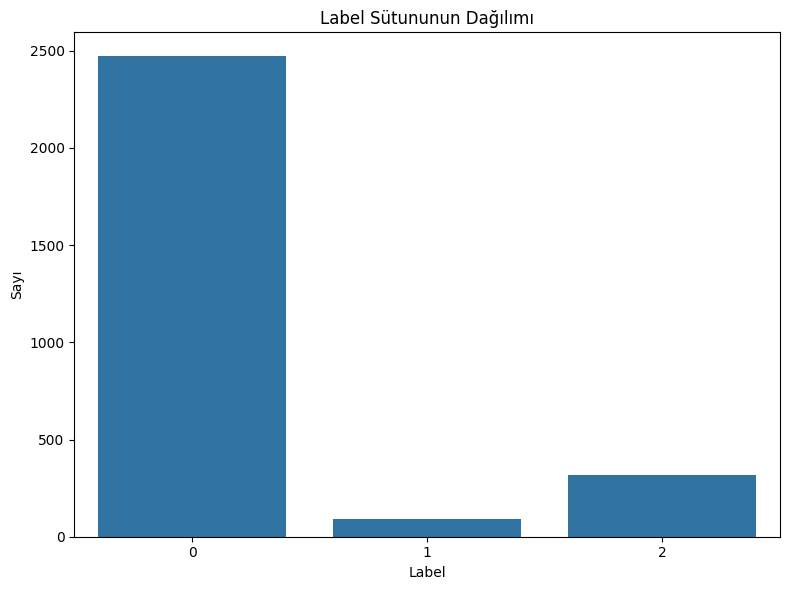

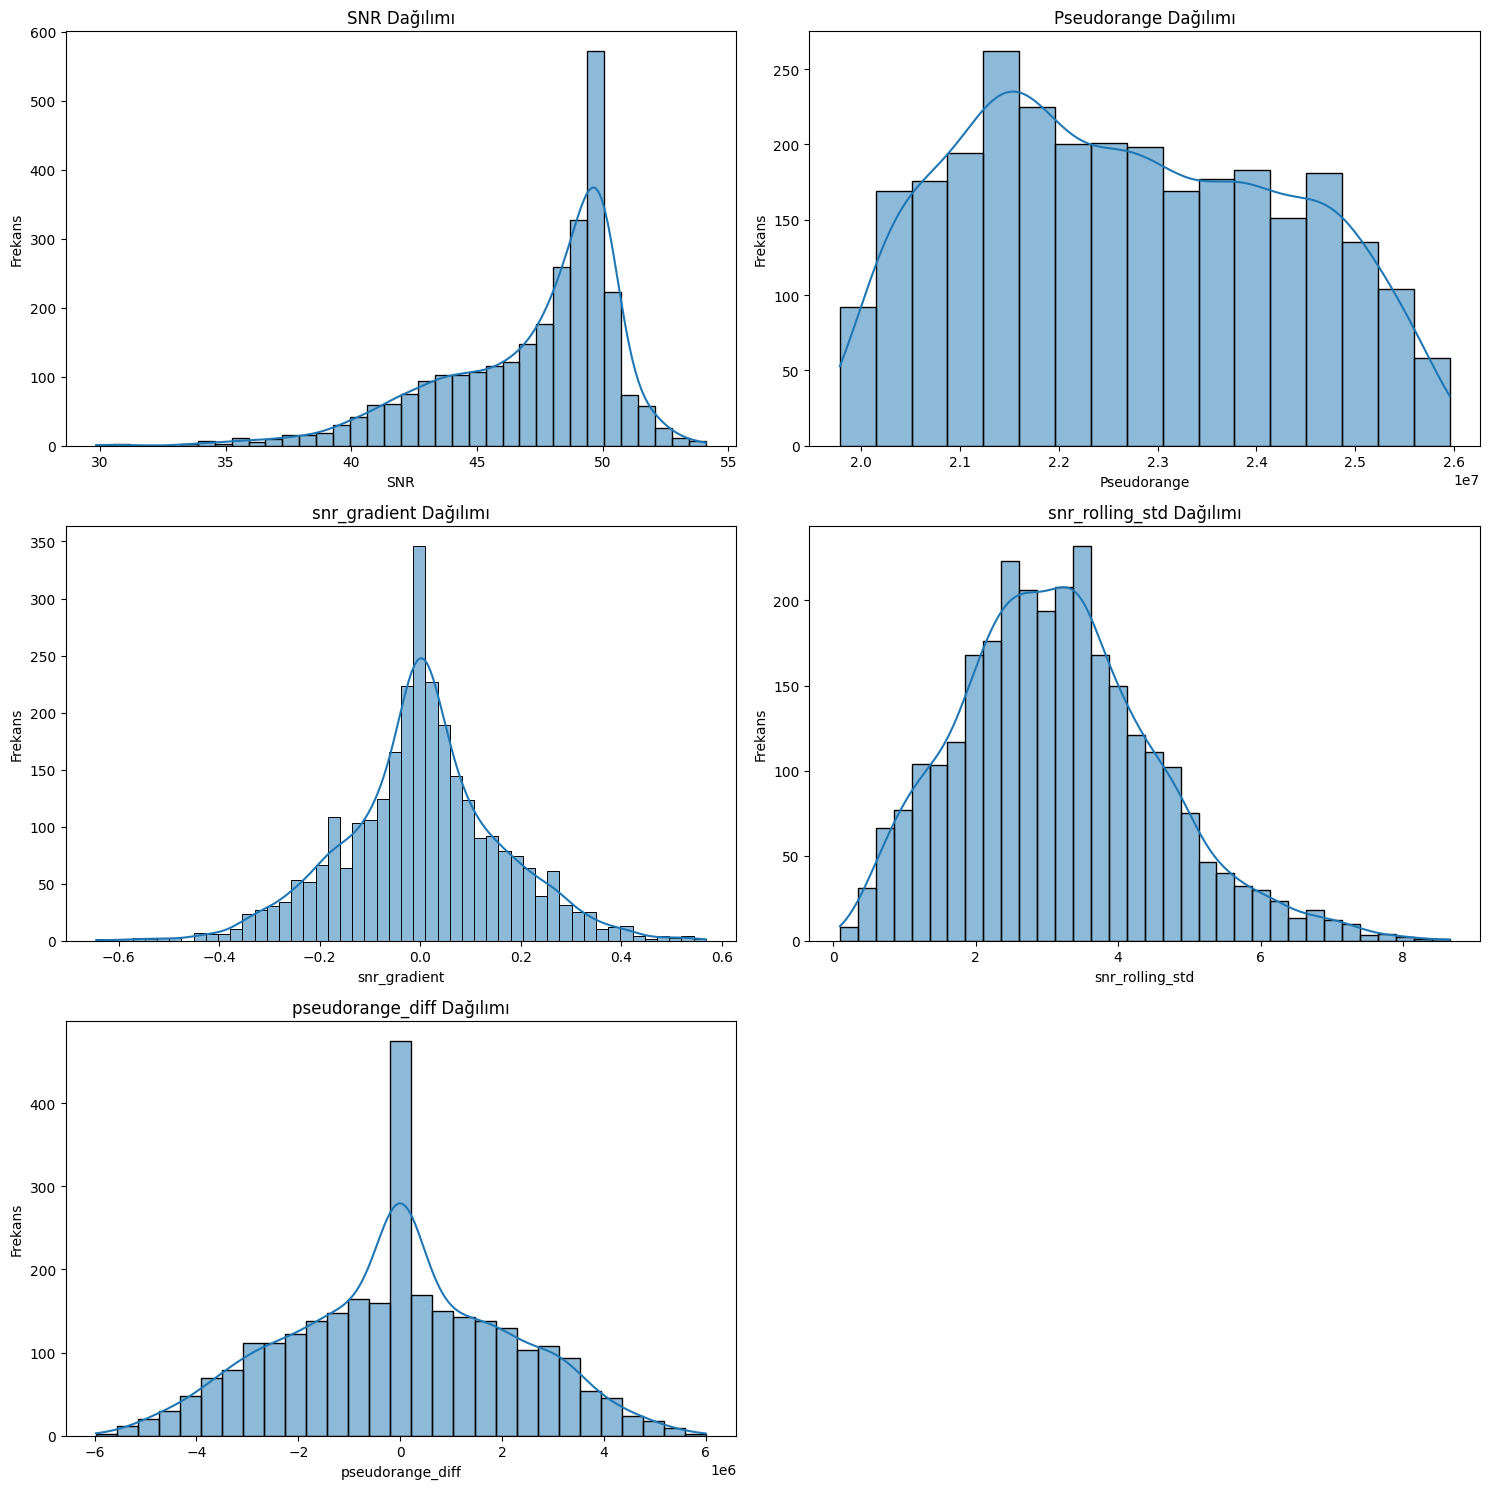

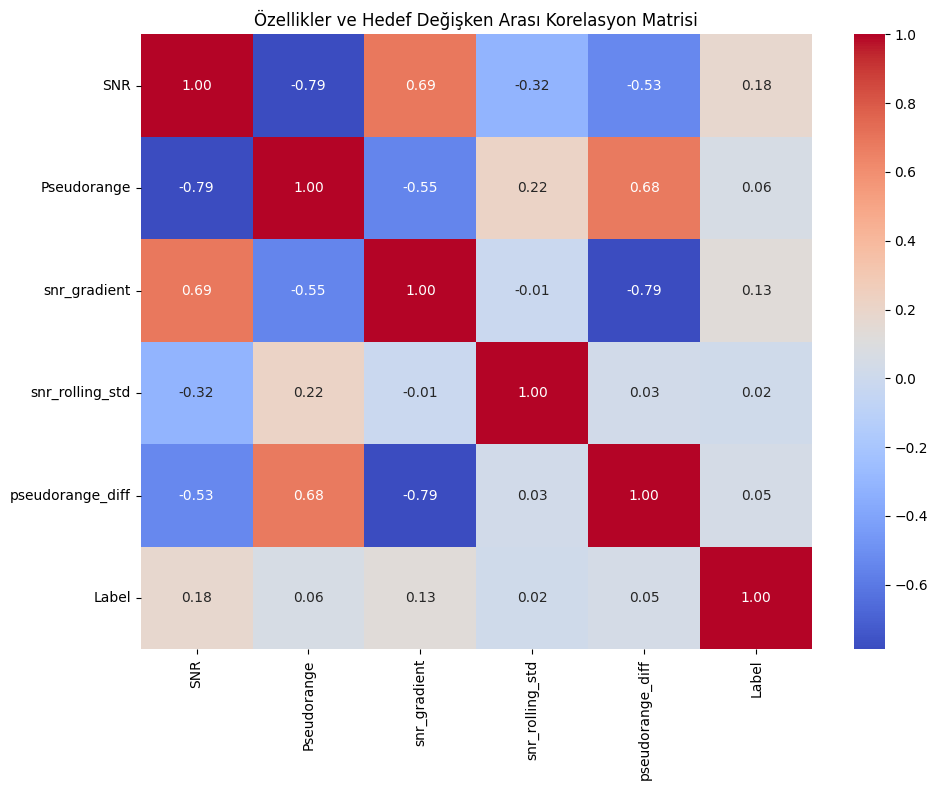


'Label' ile Özellik Korelasyonları (büyükten küçüğe):
Label               1.000000
SNR                 0.177420
snr_gradient        0.131183
Pseudorange         0.060694
pseudorange_diff    0.048261
snr_rolling_std     0.018950
Name: Label, dtype: float64

Eğitim seti boyutu : 2300
Test seti boyutu   : 575

── Model Sonuçları (Zamansal Bölme) ──
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       499
           1       0.00      0.00      0.00        25
           2       0.87      0.92      0.90        51

    accuracy                           0.94       575
   macro avg       0.60      0.64      0.62       575
weighted avg       0.90      0.94      0.92       575



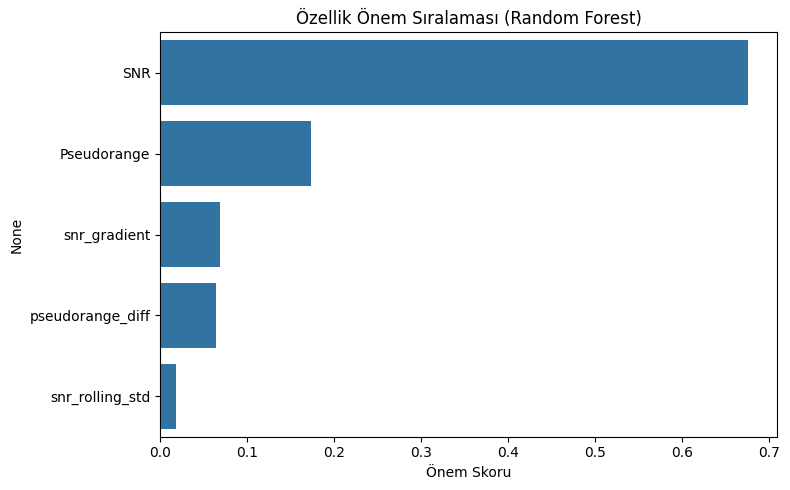

In [ ]:
# ============================================================
# GNSS Spoofing Tespiti - Düzeltilmiş ve Optimize Edilmiş Kod
# ============================================================

# ── 0. Google Drive bağlantısı (HER ŞEYDEN ÖNCE) ──────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 1. Kütüphaneler ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ── 2. Veri Yükleme ───────────────────────────────────────────
path = "/content/drive/MyDrive/vega/gnss3.csv"
df = pd.read_csv(path)
df = df.dropna().reset_index(drop=True)

# ── 3. Zaman İşlemleri ────────────────────────────────────────
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)   # Zamansal sırayı garanti et

df['time_diff'] = df['time'].diff().dt.total_seconds()

# DÜZELTME #1: time_diff = 0 olan satırlar sonsuz gradyan üretir → NaN yap
df['time_diff'] = df['time_diff'].replace(0, np.nan)

# ── 4. Özellik Mühendisliği ───────────────────────────────────

# Sinyal gürültüsü (5'lik pencere std) — ilk 4 satır NaN olarak kalır, drop edilecek
df['snr_rolling_std'] = df['SNR'].rolling(window=5).std()

# Pseudorange anlık sıçramaları
df['pseudorange_diff'] = df['Pseudorange'].diff()

# DÜZELTME #2: Gerçek residual yerine sadece merkeze alma yapılıyordu;
#              bu özellik Pseudorange ile %100 korelasyonlu olduğundan KALDIRILDI.
#              (Pseudorange - mean(Pseudorange) ekstra bilgi taşımaz)

# SNR gradyanı — time_diff NaN olan yerlerde sonuç da NaN olur (güvenli)
df['snr_gradient'] = df['SNR'].diff() / df['time_diff']

# DÜZELTME #3: inf değerlerini de temizle (dropna() tek başına inf'i silmez)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

# ── 5. Özellik Listesi ────────────────────────────────────────
# pseudorange_residual kaldırıldı (Pseudorange ile korelasyon = 1.0 → anlamsız)
features = [
    'SNR',
    'Pseudorange',
    'snr_gradient',
    'snr_rolling_std',
    'pseudorange_diff'
]

X = df[features]
y = df['Label']

# ── 6. Keşifsel Veri Analizi ──────────────────────────────────

# Genel bakış
print("=" * 60)
print("DataFrame'in ilk 5 satırı:")
print(df.head())

print("\nDataFrame Bilgisi:")
df.info()

print("\nEksik değer sayısı (temizlik sonrası):")
print(df.isnull().sum())

print("\nTanımlayıcı İstatistikler:")
print(df.describe())

print("\n'Label' sütununun değer dağılımı:")
print(df['Label'].value_counts())

# Label dağılımı
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df)
plt.title('Label Sütununun Dağılımı')
plt.xlabel('Label')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

# Özellik histogramları
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'{feature} Dağılımı')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekans')

# Fazladan eksen varsa gizle
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Korelasyon matrisi
correlation_matrix = df[features + ['Label']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Özellikler ve Hedef Değişken Arası Korelasyon Matrisi')
plt.tight_layout()
plt.show()

print("\n'Label' ile Özellik Korelasyonları (büyükten küçüğe):")
print(correlation_matrix['Label'].sort_values(ascending=False))

# ── 7. Modelleme ──────────────────────────────────────────────

# DÜZELTME #4: Zamansal sıra korunarak train/test bölmesi (data leakage önlendi)
# Rastgele karıştırma (shuffle) GNSS zaman serisi için yanlış sonuç üretir.
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"\nEğitim seti boyutu : {len(X_train)}")
print(f"Test seti boyutu   : {len(X_test)}")

# Aşırı öğrenmeyi önlemek için kısıtlı Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,         # Ağaç derinliği sınırlı
    min_samples_leaf=20, # Genelleme için minimum yaprak örneği
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n" + "=" * 60)
print("── Model Sonuçları (Zamansal Bölme) ──")
print(classification_report(y_test, y_pred))

# Özellik önem sıralaması
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Özellik Önem Sıralaması (Random Forest)')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q streamlit pyngrok

In [ ]:
from pyngrok import ngrok
import subprocess
import os
import time

# Eğer açık bir ngrok tüneli varsa kapat
print("Mevcut ngrok tünelleri kapatılıyor...")
ngrok.kill()

# Streamlit'in varsayılan portu
streamlit_port = 8501

# ngrok tüneli başlat
print(f"ngrok tüneli başlatılıyor (port: {streamlit_port})...")
tunnel = ngrok.connect(streamlit_port)
public_url = tunnel.public_url
print(f"Streamlit uygulamanıza buradan erişin: {public_url}")

# Streamlit uygulamasını başlat (non-blocking)
print("Streamlit uygulaması başlatılıyor...")

# Arka planda çalıştır
streamlit_process = subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", str(streamlit_port),
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

# Küçük bir bekleme, Streamlit’in hazır hale gelmesi için
time.sleep(5)

print("Streamlit ve ngrok aktif. Linkten erişebilirsiniz.")

Mevcut ngrok tünelleri kapatılıyor...
ngrok tüneli başlatılıyor (port: 8501)...
Streamlit uygulamanıza buradan erişin: https://chairborne-elma-nonexplanatory.ngrok-free.dev
Streamlit uygulaması başlatılıyor...
Streamlit ve ngrok aktif. Linkten erişebilirsiniz.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from streamlit_folium import st_folium
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

st.set_page_config(page_title="GNSS Antispoofing Dashboard", layout="wide", initial_sidebar_state="collapsed")

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600&display=swap');
    html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; background-color: #0a0e1a; color: #e0e6f0; }
    .stApp { background: #0a0e1a; }
    .dashboard-header { background: linear-gradient(135deg, #0d1526, #091020); border-bottom: 1px solid #1e3a5f; padding: 20px 32px 16px 32px; }
    .dashboard-title { font-family: 'Space Mono', monospace; font-size: 1.6rem; font-weight: 700; color: #00d4ff; letter-spacing: 0.08em; text-transform: uppercase; margin: 0; }
    .dashboard-subtitle { font-size: 0.8rem; color: #4a7fa5; letter-spacing: 0.15em; text-transform: uppercase; margin-top: 4px; }
    .stat-card { background: linear-gradient(135deg, #0d1a2e, #0a1525); border: 1px solid #1e3a5f; border-radius: 8px; padding: 16px 20px; text-align: center; }
    .stat-value { font-family: 'Space Mono', monospace; font-size: 1.8rem; font-weight: 700; color: #00d4ff; line-height: 1; }
    .stat-label { font-size: 0.7rem; color: #4a7fa5; letter-spacing: 0.15em; text-transform: uppercase; margin-top: 6px; }
    .stat-value.warning { color: #ff6b35; } .stat-value.ok { color: #00ff88; } .stat-value.accent { color: #ffd700; }
    .stTabs [data-baseweb="tab-list"] { background: #0d1526; border-bottom: 2px solid #1e3a5f; padding: 0 24px; gap: 0; }
    .stTabs [data-baseweb="tab"] { font-family: 'Space Mono', monospace; font-size: 0.75rem; letter-spacing: 0.12em; text-transform: uppercase; color: #4a7fa5; padding: 14px 28px; border-bottom: 3px solid transparent; background: transparent; }
    .stTabs [aria-selected="true"] { color: #00d4ff !important; border-bottom: 3px solid #00d4ff !important; background: transparent !important; }
    .stTabs [data-baseweb="tab-panel"] { padding: 0; background: #0a0e1a; }
    .badge { display: inline-block; padding: 3px 10px; border-radius: 4px; font-family: 'Space Mono', monospace; font-size: 0.7rem; font-weight: 700; }
    .badge-spoof { background: #3d1a0e; color: #ff6b35; border: 1px solid #ff6b35; }
    .badge-clean { background: #0e2e1a; color: #00ff88; border: 1px solid #00ff88; }
    .badge-warn  { background: #2e2a0e; color: #ffd700; border: 1px solid #ffd700; }
    .badge-info  { background: #0e1e3a; color: #00d4ff; border: 1px solid #00d4ff; }
    .ai-note { background: #0d1a2e; border: 1px solid #1e3a5f; border-left: 4px solid #00d4ff; border-radius: 6px; padding: 10px 16px; margin-bottom: 16px; font-size: 0.78rem; color: #7ab3cc; font-family: 'Space Mono', monospace; }
    .map-note { background: #1a1a0d; border: 1px solid #3a3a1e; border-left: 4px solid #ffd700; border-radius: 6px; padding: 10px 16px; margin-bottom: 12px; font-size: 0.78rem; color: #c0b060; font-family: 'Space Mono', monospace; }
    div[data-baseweb="select"] > div { background: #0d1526 !important; border: 1px solid #1e3a5f !important; color: #e0e6f0 !important; }
    .stTextInput input { background: #0d1526 !important; border: 1px solid #1e3a5f !important; color: #e0e6f0 !important; border-radius: 6px !important; }
    .stSlider > div > div > div { background: #00d4ff !important; }
    [data-testid="stSidebar"] { display: none; }
    .block-container { padding-top: 0 !important; padding-left: 0 !important; padding-right: 0 !important; max-width: 100% !important; }
</style>
""", unsafe_allow_html=True)


# ════════════════════════════════════════════════════════════
# GERÇEKÇİ KOORDİNAT ÜRETME
# ════════════════════════════════════════════════════════════
def simulate_realistic_coords(n, label, seed_offset=0):
    rng = np.random.default_rng(42 + seed_offset)

    if label == 1:
        hotspots = [
            (32.0,  35.0, 1.5, 2.0, 0.25),
            (35.5,  36.5, 1.0, 1.5, 0.20),
            (55.7,  37.6, 1.5, 2.5, 0.15),
            (24.0,  45.0, 2.0, 3.0, 0.10),
            (39.9,  32.8, 1.2, 1.8, 0.10),
            (36.2,  43.9, 1.0, 1.5, 0.08),
            (51.5,  -0.1, 0.8, 1.2, 0.07),
            (48.8,   2.3, 0.8, 1.2, 0.05),
        ]
    elif label == 2:
        hotspots = [
            (33.0,  36.0, 3.0, 4.0, 0.20),
            (37.0,  35.0, 2.5, 3.5, 0.20),
            (50.0,  30.0, 4.0, 6.0, 0.15),
            (41.0,  29.0, 2.0, 3.0, 0.15),
            (40.0,  50.0, 3.0, 4.0, 0.10),
            (45.0,  15.0, 4.0, 5.0, 0.10),
            (52.0,  20.0, 3.0, 4.0, 0.10),
        ]
    else:
        hotspots = [
            (48.0,  15.0, 8.0, 12.0, 0.20),
            (41.0,  29.0, 3.0,  5.0, 0.15),
            (55.0,  40.0, 6.0, 10.0, 0.15),
            (35.0,  25.0, 4.0,  7.0, 0.12),
            (25.0,  45.0, 4.0,  6.0, 0.10),
            (60.0,  25.0, 5.0,  8.0, 0.08),
            (30.0,  31.0, 3.0,  4.0, 0.10),
            (45.0,  75.0, 5.0,  8.0, 0.10),
        ]

    weights = np.array([h[4] for h in hotspots])
    weights /= weights.sum()
    counts  = rng.multinomial(n, weights)

    lats, lons = [], []
    for (clat, clon, slat, slon, _), cnt in zip(hotspots, counts):
        lats.append(rng.normal(clat, slat, cnt))
        lons.append(rng.normal(clon, slon, cnt))

    lats = np.clip(np.concatenate(lats), -85, 85)
    lons = np.clip(np.concatenate(lons), -180, 180)

    idx = rng.permutation(len(lats))
    return lats[idx], lons[idx]


# ════════════════════════════════════════════════════════════
# AI ANALİZ FONKSİYONU
# ════════════════════════════════════════════════════════════
@st.cache_data
def run_ai_analysis():
    try:
        _raw = pd.read_csv("/content/drive/MyDrive/vega/gnss3.csv")
        _raw = _raw.dropna().reset_index(drop=True)
        _raw['time'] = pd.to_datetime(_raw['time'])
        _raw = _raw.sort_values('time').reset_index(drop=True)

        _td       = _raw['time'].diff().dt.total_seconds().replace(0, np.nan)
        _snr_std  = _raw['SNR'].rolling(window=5).std()
        _pr_diff  = _raw['Pseudorange'].diff()
        _snr_grad = _raw['SNR'].diff() / _td

        _feat = pd.DataFrame({'f1': _snr_std, 'f2': _pr_diff, 'f3': _snr_grad})
        _y    = _raw['Label'].copy()
        _time = _raw['time'].copy()

        _all = pd.concat([_feat, _y, _time], axis=1)
        _all = _all.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

        X     = _all[['f1', 'f2', 'f3']]
        y     = _all['Label']
        times = _all['time']

        split = int(len(X) * 0.8)
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        )
        rf.fit(X.iloc[:split], y.iloc[:split])

        pred  = rf.predict(X)
        proba = rf.predict_proba(X).max(axis=1)

        def _norm(s):
            mn, mx = s.min(), s.max()
            return (s - mn) / (mx - mn) if mx != mn else pd.Series(0.0, index=s.index)

        hibrit = (0.6 * _norm(X['f1'].abs()) + 0.4 * _norm(X['f2'].abs())).values

        risk_map = {0: "🟢 Temiz", 1: "🔴 Spoofing", 2: "🟡 Şüpheli"}
        risk = [risk_map.get(int(p), "⚪ Bilinmiyor") for p in pred]

        all_lats = np.zeros(len(y))
        all_lons = np.zeros(len(y))
        for lbl in y.unique():
            idx = y[y == lbl].index
            lats, lons = simulate_realistic_coords(len(idx), int(lbl), seed_offset=int(lbl)*100)
            all_lats[idx] = lats
            all_lons[idx] = lons

        # Sadece AI çıktıları — CSV etiketleri YOK
        ai_df = pd.DataFrame({
            'Zaman':                times.values,
            'Analiz Sonucu':        pred.astype(int),
            'Güven Skoru':          np.round(proba, 4),
            'Hibrit Anomali Skoru': np.round(hibrit, 4),
            'Risk Seviyesi':        risk,
            '_lat':                 np.round(all_lats, 5),
            '_lon':                 np.round(all_lons, 5),
        })

        return ai_df

    except Exception as e:
        import traceback
        st.error(f"AI analiz hatası: {e}\n{traceback.format_exc()}")
        return pd.DataFrame()


with st.spinner("🤖 AI modeli çalışıyor, veriler analiz ediliyor..."):
    df = run_ai_analysis()


# ── Başlık ───────────────────────────────────────────────────
st.markdown("""
<div class="dashboard-header">
    <div class="dashboard-title">⬡ GNSS Antispoofing Dashboard</div>
    <div class="dashboard-subtitle">AI-Powered Signal Intelligence · Random Forest Anomaly Detection</div>
</div>
""", unsafe_allow_html=True)

# ── Stat Kartları ─────────────────────────────────────────────
if not df.empty:
    total = len(df)
    clean = (df['Analiz Sonucu'] == 0).sum()
    spoof = (df['Analiz Sonucu'] == 1).sum()
    suphe = (df['Analiz Sonucu'] == 2).sum()

    st.markdown("<div style='padding:16px 24px 8px 24px;'>", unsafe_allow_html=True)
    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown(f'<div class="stat-card"><div class="stat-value">{total:,}</div><div class="stat-label">Analiz Edilen</div></div>', unsafe_allow_html=True)
    with c2:
        st.markdown(f'<div class="stat-card"><div class="stat-value ok">{clean:,}</div><div class="stat-label">Temiz Sinyal</div></div>', unsafe_allow_html=True)
    with c3:
        st.markdown(f'<div class="stat-card"><div class="stat-value warning">{spoof:,}</div><div class="stat-label">Spoofing Tespit</div></div>', unsafe_allow_html=True)
    with c4:
        st.markdown(f'<div class="stat-card"><div class="stat-value accent">{suphe:,}</div><div class="stat-label">Şüpheli Sinyal</div></div>', unsafe_allow_html=True)
    st.markdown("</div>", unsafe_allow_html=True)

tab1, tab2 = st.tabs(["🌍  Harita Görünümü", "🤖  AI Analiz Sonuçları"])


# ════════════════════════════════════════
# TAB 1: HARİTA — TEK HARİTA (MODEL TAHMİNİ)
# ════════════════════════════════════════
with tab1:
    st.markdown("<div style='padding:16px 24px 0 24px;'>", unsafe_allow_html=True)

    st.markdown("""<div class="map-note">
        ⬡ Koordinatlar simüle edilmiştir — gerçek konumları temsil etmez.
        Renk kodlaması AI modelinin analiz sonucunu gösterir.
    </div>""", unsafe_allow_html=True)

    col_f1, col_f2 = st.columns([1, 2])
    with col_f1:
        map_style = st.selectbox("Harita Teması", ["CartoDB dark_matter", "CartoDB positron", "OpenStreetMap"], key="map_style")
    with col_f2:
        skor_range = st.slider("Anomali Skoru Filtresi", 0.0, 1.0, (0.0, 1.0), step=0.01, key="map_skor")

    st.markdown("</div>", unsafe_allow_html=True)

    if not df.empty:
        map_df = df[
            (df['Hibrit Anomali Skoru'] >= skor_range[0]) &
            (df['Hibrit Anomali Skoru'] <= skor_range[1])
        ].copy()

        cmap = {0: "#00ff88", 1: "#ff4444", 2: "#ffd700"}
        label_name = {0: "Temiz", 1: "Spoofing", 2: "Şüpheli"}

        clat = map_df['_lat'].mean() if len(map_df) > 0 else 39.0
        clon = map_df['_lon'].mean() if len(map_df) > 0 else 20.0
        m = folium.Map(location=[clat, clon], zoom_start=3, tiles=map_style)

        for _, row in map_df.iterrows():
            val   = int(row['Analiz Sonucu'])
            color = cmap.get(val, "#aaaaaa")
            name  = label_name.get(val, str(val))
            popup = f"""<div style='font-family:monospace;font-size:11px;background:#0d1526;color:#e0e6f0;padding:8px;border-radius:6px;min-width:180px;'>
                <b style='color:{color}'>{name}</b><hr style='margin:3px 0;border-color:#1e3a5f'>
                <b>Analiz Sonucu:</b> {name}<br>
                <b>Güven:</b> {row['Güven Skoru']:.2%}<br>
                <b>Anomali:</b> {row['Hibrit Anomali Skoru']:.4f}
            </div>"""
            folium.CircleMarker(
                location=[row['_lat'], row['_lon']],
                radius=6 if val == 1 else 4,
                color=color, fill=True, fill_color=color,
                fill_opacity=0.85, weight=1.2,
                popup=folium.Popup(popup, max_width=220),
                tooltip=f"{name} | {row['Hibrit Anomali Skoru']:.3f}"
            ).add_to(m)

        legend = """<div style="position:fixed;bottom:25px;left:15px;z-index:1000;
            background:#0d1526;border:1px solid #1e3a5f;padding:10px 14px;
            border-radius:8px;font-family:monospace;font-size:11px;color:#e0e6f0;">
            <b style="color:#00d4ff;">ANALİZ SONUCU</b><br>
            <span style="color:#00ff88">●</span> Temiz<br>
            <span style="color:#ff4444">●</span> Spoofing<br>
            <span style="color:#ffd700">●</span> Şüpheli
        </div>"""
        m.get_root().html.add_child(folium.Element(legend))

        st_folium(m, width="100%", height=560, key="map_ana", returned_objects=[])

        st.markdown(f"""
        <div style='display:flex;gap:12px;padding:12px 0 8px 0;flex-wrap:wrap;'>
            <span class='badge badge-clean'>🟢 Temiz: {(map_df['Analiz Sonucu']==0).sum():,}</span>
            <span class='badge badge-spoof'>🔴 Spoofing: {(map_df['Analiz Sonucu']==1).sum():,}</span>
            <span class='badge badge-warn'>🟡 Şüpheli: {(map_df['Analiz Sonucu']==2).sum():,}</span>
            <span style='font-family:monospace;font-size:0.75rem;color:#4a7fa5;margin-left:auto;'>{len(map_df):,} SİNYAL</span>
        </div>""", unsafe_allow_html=True)


# ════════════════════════════════════════
# TAB 2: AI ANALİZ SONUÇLARI
# ════════════════════════════════════════
with tab2:
    st.markdown("<div style='padding:20px 24px;'>", unsafe_allow_html=True)

    st.markdown("""<div class="ai-note">
        ⬡ Bu tabloda yalnızca AI modelinin (Random Forest) ürettiği analiz sonuçları yer almaktadır.
        SNR, Pseudorange gibi ham sensör verileri bu tabloda yer almaz.
    </div>""", unsafe_allow_html=True)

    if not df.empty:
        col_t1, col_t2 = st.columns([1, 2])
        with col_t1:
            tbl_risk = st.multiselect("Risk Seviyesi", options=sorted(df['Risk Seviyesi'].unique().tolist()), default=sorted(df['Risk Seviyesi'].unique().tolist()), key="tbl_risk")
        with col_t2:
            tbl_skor = st.slider("Anomali Skoru", 0.0, 1.0, (0.0, 1.0), step=0.01, key="tbl_skor")

        TABLE_COLS = ['Zaman', 'Analiz Sonucu', 'Güven Skoru', 'Hibrit Anomali Skoru', 'Risk Seviyesi']

        tbl_df = df[
            (df['Risk Seviyesi'].isin(tbl_risk)) &
            (df['Hibrit Anomali Skoru'] >= tbl_skor[0]) &
            (df['Hibrit Anomali Skoru'] <= tbl_skor[1])
        ][TABLE_COLS].copy().sort_values('Hibrit Anomali Skoru', ascending=False).reset_index(drop=True)

        sp = (tbl_df['Risk Seviyesi'] == "🔴 Spoofing").sum()
        te = (tbl_df['Risk Seviyesi'] == "🟢 Temiz").sum()
        su = (tbl_df['Risk Seviyesi'] == "🟡 Şüpheli").sum()

        st.markdown(f"""<div style='display:flex;gap:12px;margin-bottom:16px;align-items:center;flex-wrap:wrap;'>
            <span class='badge badge-clean'>🟢 Temiz: {te}</span>
            <span class='badge badge-spoof'>🔴 Spoofing: {sp}</span>
            <span class='badge badge-warn'>🟡 Şüpheli: {su}</span>
            <span style='font-family:monospace;font-size:0.75rem;color:#4a7fa5;margin-left:auto;'>{len(tbl_df):,} SATIR</span>
        </div>""", unsafe_allow_html=True)

        st.dataframe(tbl_df, use_container_width=True, height=520, hide_index=True)

        csv = tbl_df.to_csv(index=False).encode('utf-8')
        st.download_button("⬇  AI Analiz Sonuçlarını İndir (CSV)", data=csv, file_name="gnss_ai_analiz.csv", mime="text/csv", key="dl_csv")

    else:
        st.warning("Analiz sonucu bulunamadı.")

    st.markdown("</div>", unsafe_allow_html=True)

Overwriting app.py
